# Análise de Replay de Mercado Estático

Este notebook gera um gráfico de candles para um dia específico e, em seguida, analisa cada candle para gerar um relatório de todas as sugestões de operação que o modelo de IA teria fornecido.

**Funcionalidades:**
- Busca dados de um período estendido (dia do replay + 6 dias anteriores) para garantir a precisão dos indicadores.
- Exibe um gráfico completo apenas para o dia do replay, com candles de M5, médias móveis "aquecidas" e setas indicando os sinais de Compra/Venda.
- Apresenta um relatório detalhado com todas as operações sugeridas.
- Exporta um relatório completo (gráfico + tabela) em um único arquivo HTML.

### Passo 1: Configuração da Análise

**Ação:** Defina as variáveis `TICKER` e `REPLAY_DATETIME_STR`.

In [ ]:
# --- PARÂMETROS DE ENTRADA ---
TICKER = "WDO$"  # Ativo para o replay (deve estar no main.yaml)
REPLAY_DATETIME_STR = "2025-10-06" # Data ('YYYY-MM-DD') ou Data e Hora ('YYYY-MM-DD HH:MM')
# ---------------------------

print(f"Configurado para análise do ativo '{TICKER}' em '{REPLAY_DATETIME_STR}'.")

Configurado para análise do ativo 'WDO$' em '2025-10-06'.


### Passo 2: Importações e Preparação do Ambiente

In [ ]:
import yaml
import logging
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import pytz
import MetaTrader5 as mt5
import mplfinance as mpf
import sys
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import importlib

# Adiciona a pasta 'src' ao path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.strategies.lstm import KerasLSTMWrapper

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Carrega as configurações
with open(project_root / "configs/main.yaml", "r") as file:
    config = yaml.safe_load(file)

asset_config = next((asset for asset in config['assets'] if asset['ticker'] == TICKER), None)
if not asset_config:
    raise ValueError(f"Ticker '{TICKER}' não encontrado em configs/main.yaml.")

### Passo 3: Geração do Gráfico e Relatório de Sinais

2025-10-12 14:33:34,486 - INFO - Conectando ao MT5 para buscar candles de M5 de 2025-09-30 até 2025-10-06...
2025-10-12 14:33:38,079 - INFO - 570 candles de M5 carregados no total.
2025-10-12 14:33:38,086 - INFO - Gerando relatório de sinais de operação...
2025-10-12 14:33:38,086 - INFO - Carregando modelo de c:\projects\wtnps-trade\models\WDO$_prod_model.keras e scaler de c:\projects\wtnps-trade\models\WDO$_prod_scaler.joblib
c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\wtnps-trade-VyqtAXyS-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
13/13 ━━━━━━━━━━━━━━━━━

2025-10-12 14:34:10,419 - INFO - Gerando gráfico estático com sinais...


,Candle de Entrada,Tipo de Operação,Preço Sugerido,Preço de Stop
0,2025-10-06 09:00,Compra,5377.50,5269.95
1,2025-10-06 09:05,Compra,5378.00,5270.44
2,2025-10-06 09:10,Compra,5366.00,5258.68
3,2025-10-06 09:15,Compra,5365.50,5258.19
4,2025-10-06 09:20,Compra,5367.50,5260.15
...,...,...,...,...
109,2025-10-06 18:05,Compra,5347.50,5240.55
110,2025-10-06 18:10,Compra,5345.00,5238.10
111,2025-10-06 18:15,Compra,5343.50,5236.63
112,2025-10-06 18:20,Compra,5345.50,5238.59


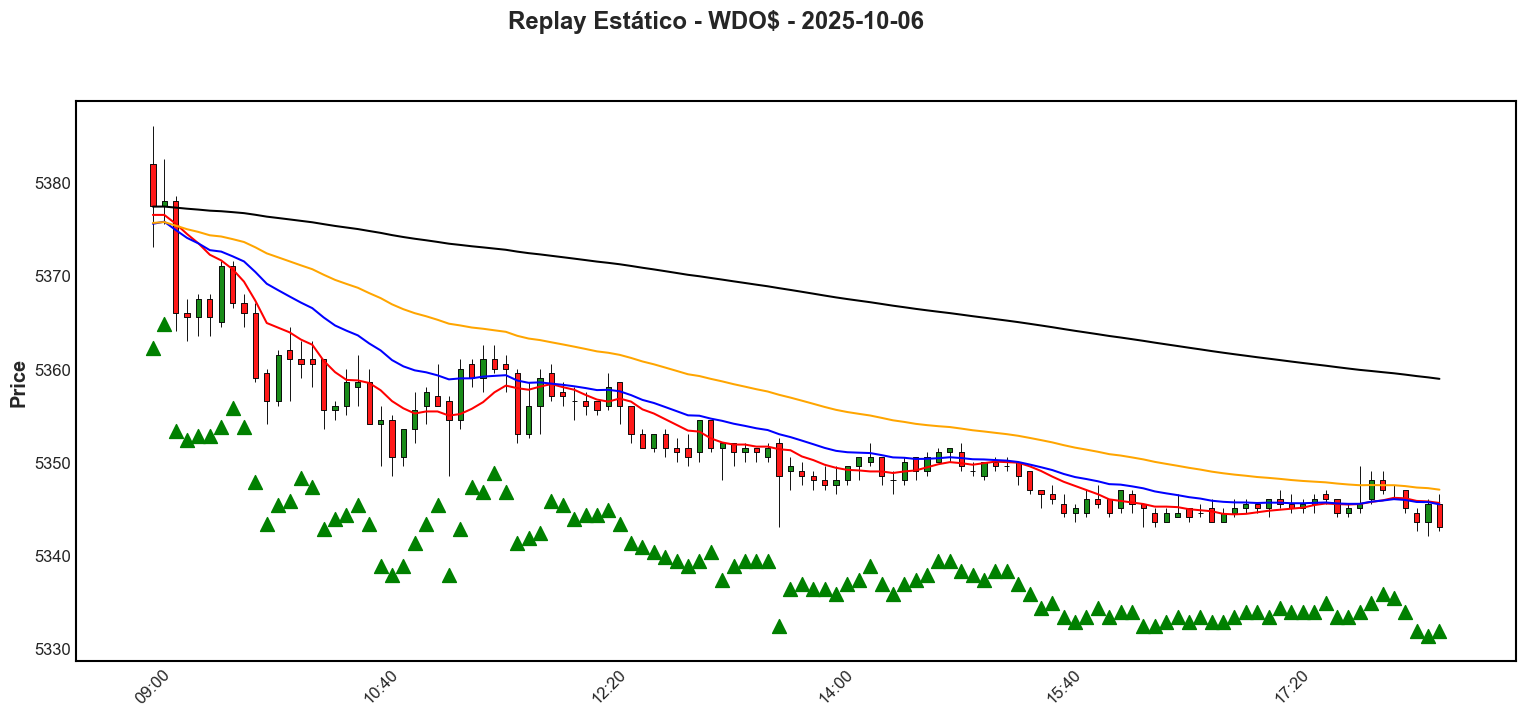

In [ ]:
def generate_static_replay_and_report(ticker, datetime_str, asset_config):
    # 1. Processar data e hora
    try:
        end_dt_obj = datetime.strptime(datetime_str, '%Y-%m-%d %H:%M')
        replay_day_start = end_dt_obj.replace(hour=0, minute=0, second=0)
    except ValueError:
        replay_day_start = datetime.strptime(datetime_str, '%Y-%m-%d')
        end_dt_obj = replay_day_start.replace(hour=23, minute=59, second=59)

    fetch_start_obj = replay_day_start - timedelta(days=6)
    timezone = pytz.timezone("Etc/UTC")
    start_time_utc = timezone.localize(fetch_start_obj)
    end_time_utc = timezone.localize(end_dt_obj)

    # 2. Buscar dados de candles M5
    logging.info(f"Conectando ao MT5 para buscar candles de M5 de {start_time_utc.date()} até {end_time_utc.date()}...")
    if not mt5.initialize():
        logging.error(f"Falha na inicialização do MT5: {mt5.last_error()}")
        return None, None
    
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_M5, start_time_utc, end_time_utc)
    mt5.shutdown()

    if rates is None or len(rates) == 0:
        logging.error("Nenhum dado de candle encontrado para o período.")
        return None, None
    
    full_candles_df = pd.DataFrame(rates)
    full_candles_df['time'] = pd.to_datetime(full_candles_df['time'], unit='s')
    full_candles_df.set_index('time', inplace=True)
    full_candles_df.rename(columns={'tick_volume': 'volume'}, inplace=True)
    logging.info(f"{len(full_candles_df)} candles de M5 carregados no total.")

    # 3. Calcular indicadores
    full_candles_df['sma9'] = full_candles_df['close'].rolling(window=9).mean()
    full_candles_df['ema21'] = full_candles_df['close'].ewm(span=21, adjust=False).mean()
    full_candles_df['ema50'] = full_candles_df['close'].ewm(span=50, adjust=False).mean()
    full_candles_df['ema200'] = full_candles_df['close'].ewm(span=200, adjust=False).mean()

    # 4. Gerar Relatório de Sinais
    logging.info("Gerando relatório de sinais de operação...")
    replay_day_candles_df = full_candles_df[full_candles_df.index.date == replay_day_start.date()].copy()

    models_dir = project_root / config["global_settings"]["model_directory"]
    model_path = models_dir / f"{ticker}_prod_model.keras"
    scaler_path = models_dir / f"{ticker}_prod_scaler.joblib"

    if not model_path.exists():
        logging.error(f"Modelo para {ticker} não encontrado.")
        return None, None
        
    model = KerasLSTMWrapper.load_model(str(model_path), str(scaler_path))
    strategy_module = importlib.import_module(f"src.strategies.{asset_config['strategy_module']}")
    StrategyClass = getattr(strategy_module, asset_config['strategy_name'])
    strategy = StrategyClass()

    suggestions = []
    for i in range(len(replay_day_candles_df)):
        current_candle_time = replay_day_candles_df.index[i]
        data_for_prediction = full_candles_df[full_candles_df.index <= current_candle_time]
        
        featured_data = strategy.define_features(data_for_prediction)
        X_live = featured_data[strategy.get_feature_names()].dropna()

        if len(X_live) > model.lookback:
            signal = model.predict(X_live)[-1]
            entry_price = replay_day_candles_df['close'].iloc[i]
            stop_loss_pct = asset_config['trading_rules']['stop_loss_pct']
            stop_price = entry_price * (1 - stop_loss_pct) if signal == 1 else entry_price * (1 + stop_loss_pct)
            
            suggestions.append({
                "Candle de Entrada": current_candle_time.strftime('%Y-%m-%d %H:%M'),
                "Tipo de Operação": "Compra" if signal == 1 else "Venda",
                "Preço Sugerido": f"{entry_price:.2f}",
                "Preço de Stop": f"{stop_price:.2f}",
                "signal": signal, "timestamp": current_candle_time
            })
    
    report_df = pd.DataFrame(suggestions)

    # 5. Preparar dados para o Gráfico
    plot_df = replay_day_candles_df
    
    # 6. Gerar Gráfico
    chart_style = mpf.make_mpf_style(base_mpf_style='default', marketcolors=mpf.make_marketcolors(up='g', down='r'), facecolor='white', gridstyle='-')
    
    addplots = [
        mpf.make_addplot(plot_df['sma9'], color='red'),
        mpf.make_addplot(plot_df['ema21'], color='blue'),
        mpf.make_addplot(plot_df['ema50'], color='orange'),
        mpf.make_addplot(plot_df['ema200'], color='black'),
    ]
    
    # --- CORREÇÃO AQUI: Adiciona os marcadores de sinal condicionalmente ---
    if not report_df.empty:
        buy_signals = report_df[report_df['signal'] == 1]
        sell_signals = report_df[report_df['signal'] == 0]
        
        if not buy_signals.empty:
            buy_indices = plot_df.index.intersection(buy_signals['timestamp'])
            buy_markers = pd.Series(np.nan, index=plot_df.index)
            buy_markers.loc[buy_indices] = plot_df.loc[buy_indices, 'low'] * 0.998
            addplots.append(mpf.make_addplot(buy_markers, type='scatter', marker='^', color='green', markersize=100))

        if not sell_signals.empty:
            sell_indices = plot_df.index.intersection(sell_signals['timestamp'])
            sell_markers = pd.Series(np.nan, index=plot_df.index)
            sell_markers.loc[sell_indices] = plot_df.loc[sell_indices, 'high'] * 1.002
            addplots.append(mpf.make_addplot(sell_markers, type='scatter', marker='v', color='red', markersize=100))

    logging.info("Gerando gráfico estático com sinais...")
    fig, axes = mpf.plot(plot_df, type='candle', style=chart_style, addplot=addplots, 
                         figsize=(20, 8), title=f"Replay Estático - {ticker} - {replay_day_start.date()}",
                         returnfig=True)
    
    # Exibe o relatório
    final_report_df = pd.DataFrame()
    if not report_df.empty:
        final_report_df = report_df.drop(columns=['signal', 'timestamp'])
        display(final_report_df)
    else:
        print("Nenhuma sugestão de operação foi gerada para este período.")
        
    return fig, final_report_df

# Executa a função principal
fig, report_df = generate_static_replay_and_report(TICKER, REPLAY_DATETIME_STR, asset_config)

### Passo 4: Exportar Relatório Consolidado (Gráfico + Tabela)

In [ ]:
def export_full_report(figure, report_dataframe, ticker, date_str):
    if figure is None:
        logging.error("Figura do gráfico não foi gerada. Não é possível exportar.")
        return

    # Salvar a figura em memória
    img_buffer = BytesIO()
    figure.savefig(img_buffer, format='png', bbox_inches='tight')
    img_base64 = base64.b64encode(img_buffer.getvalue()).decode('utf-8')
    img_src = f"data:image/png;base64,{img_base64}"
    plt.close(figure)

    # Converter o DataFrame para HTML
    table_html = report_dataframe.to_html(index=False, classes='styled-table', border=0) if not report_dataframe.empty else "<p>Nenhuma operação sugerida.</p>"

    # Montar o template HTML final
    html_template = f"""
    <html>
    <head>
        <title>Relatório de Análise - {ticker} - {date_str}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 20px; }}
            h1, h2 {{ color: #333; }}
            .styled-table {{ border-collapse: collapse; margin: 25px 0; font-size: 0.9em; min-width: 400px; box-shadow: 0 0 20px rgba(0, 0, 0, 0.15); width: 100%; }}
            .styled-table thead tr {{ background-color: #009879; color: #ffffff; text-align: left; }}
            .styled-table th, .styled-table td {{ padding: 12px 15px; }}
            .styled-table tbody tr {{ border-bottom: 1px solid #dddddd; }}
            img {{ max-width: 100%; height: auto; }}
        </style>
    </head>
    <body>
        <h1>Relatório de Análise Estática</h1>
        <h2>Ativo: {ticker} | Data: {date_str.split(' ')[0]}</h2>
        
        <h2>Gráfico de Candlesticks com Sinais</h2>
        <img src='{img_src}'>
        
        <h2>Relatório de Sinais de Operação</h2>
        {table_html}
    </body>
    </html>
    """

    # Salvar o arquivo HTML
    report_filename = f"static_replay_{ticker}_{date_str.split(' ')[0]}.html"
    reports_dir = project_root / "reports"
    reports_dir.mkdir(exist_ok=True)
    output_path = reports_dir / report_filename

    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(html_template)
    
    logging.info(f"Relatório completo salvo em: {output_path}")

# Executa a exportação
export_full_report(fig, report_df, TICKER, REPLAY_DATETIME_STR)

2025-10-12 14:34:10,866 - INFO - Relatório completo salvo em: c:\projects\wtnps-trade\reports\static_replay_WDO$_2025-10-06.html
